# MPPI Drone Racing — JAX GPU
Upload the repo zip, then run cells in order.

In [3]:
from google.colab import files
uploaded = files.upload()

Saving Mobile-Robot---MPPI-Based-Autonomous-Drone-Racing.zip to Mobile-Robot---MPPI-Based-Autonomous-Drone-Racing.zip


In [4]:
import zipfile, os
zip_name = list(uploaded.keys())[0]
with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall('/content/repo')
src_path = None
for root, dirs, files_ in os.walk('/content/repo'):
    if 'mppi_controller.py' in files_:
        src_path = root
        break
print('src path:', src_path)

src path: /content/repo/Mobile-Robot---MPPI-Based-Autonomous-Drone-Racing/src


In [5]:
!pip install pyyaml tqdm scipy spatialmath-python --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.5/193.5 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.4/226.4 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.4/99.4 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 111.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 469.0/469.0 kB 36.3 MB/s eta 0:00:00


In [6]:
import sys
sys.path.insert(0, src_path)
os.chdir(src_path)

In [ ]:

K = 10000  
T = 100    
sigma = 100.0
n_iter = 5      
k_progress = 1.0
k_offset = 0.0
max_speed = 20.0

In [178]:
import numpy as np
import jax
import jax.numpy as jnp
from tqdm import tqdm

from quadrotor_simulator_py.quadrotor_model import QuadrotorModel
from Env import RaceEnvironment
from mppi_controller import compute_hover_rpm

print('JAX devices:', jax.devices())

JAX devices: [CudaDevice(id=0)]


In [179]:
model = QuadrotorModel()
model.initialize(src_path + '/config/rocky0704_model_params.yaml')
model.reset_simulation()
model.set_pose(np.array([0.0, 0.0, 2.0, 1.0, 0.0, 0.0, 0.0]))
rpm_hover = compute_hover_rpm(model)
model.rs = np.ones(4) * rpm_hover
model.model_params.uRPM = np.ones((4, 1)) * rpm_hover
print(f'Hover RPM: {rpm_hover:.1f}')

env = RaceEnvironment()
print(f'Track length: {env.total_length:.1f} m')

Hover RPM: 13246.6
Track length: 118.9 m


In [ ]:
def make_jax_mppi(model, env):
    p = model.model_params
    stride = max(1, len(env.waypoints) // 200)

    params = {
        'motor'       : jnp.array(p.motor_model.flatten()),
        'mixer'       : jnp.array(p.mixer),
        'inertia'     : jnp.array(p.inertia),
        'inertia_inv' : jnp.array(p.inertia_inv),
        'mass'        : float(p.mass),
        'gravity'     : float(p.gravity_norm),
        'kmotor_u'    : float(p.kmotor_u),
        'kmotor_d'    : float(p.kmotor_d),
        'rpm_min'     : float(p.rpm_params.min),
        'rpm_max'     : float(p.rpm_params.max),
        'wp'          : jnp.array(env.waypoints[::stride]),
        'arc'         : jnp.array(env._arc_lengths[::stride]),
        'obs_centers' : jnp.array(np.stack([o['center'] for o in env.obstacles])),
        'obs_radii'   : jnp.array(np.array([o['radius'] for o in env.obstacles])),
        'drone_radius': float(env.drone_radius),
        'tube_radius' : float(env.tube_radius),
        'total_length': float(env.total_length),
        'dt'          : 0.02,
        'k_progress'  : k_progress,
        'k_offset'    : k_offset,
        'max_speed'   : max_speed,
        'sigma'       : sigma,
        'penalty'     : 2.0 * (k_offset+k_progress) * T,
    }

    def ode_batch(X, U):
        rpms = X[:, 13:17]
        o = jnp.stack([rpms**2, rpms, jnp.ones_like(rpms)], axis=2)
        thrust = o @ params['motor']
        result = (params['mixer'] @ thrust.T).T
        F, M = result[:, 0], result[:, 1:]

        qw, qx, qy, qz = X[:,3], X[:,4], X[:,5], X[:,6]
        zb = jnp.stack([
            2*(qx*qz + qw*qy),
            2*(qy*qz - qw*qx),
            1 - 2*(qx**2 + qy**2),
        ], axis=1)
        lin_acc = jnp.array([0., 0., -params['gravity']]) + (F / params['mass'])[:, None] * zb

        wb = X[:, 10:13]
        Icm_wb = (params['inertia'] @ wb.T).T
        ang_acc = (params['inertia_inv'] @ (-jnp.cross(wb, Icm_wb) + M).T).T

        dq = 0.5 * jnp.stack([
            -qx*wb[:,0] - qy*wb[:,1] - qz*wb[:,2],
             qw*wb[:,0] + qy*wb[:,2] - qz*wb[:,1],
             qw*wb[:,1] - qx*wb[:,2] + qz*wb[:,0],
             qw*wb[:,2] + qx*wb[:,1] - qy*wb[:,0],
        ], axis=1)

        w_cur = X[:, 13:17]
        k_m = jnp.where(U >= w_cur, params['kmotor_u'], params['kmotor_d'])
        drpm = (w_cur - U) * -k_m

        return jnp.concatenate([X[:,7:10], dq, lin_acc, ang_acc, drpm], axis=1)

    def step_batch(X, U):
        dt = params['dt']
        k1 = ode_batch(X, U)
        k2 = ode_batch(X + dt/2 * k1, U)
        k3 = ode_batch(X + dt/2 * k2, U)
        k4 = ode_batch(X + dt * k3, U)
        X_new = X + (dt/6) * (k1 + 2*k2 + 2*k3 + k4)
        q = X_new[:, 3:7]
        X_new = X_new.at[:, 3:7].set(q / jnp.linalg.norm(q, axis=1, keepdims=True))
        return X_new

    def rollout_step(carry, inp):
        X, costs, x0_progress = carry
        eps_t, U_t, t = inp

        U_cmd = jnp.clip(U_t + eps_t, params['rpm_min'], params['rpm_max'])
        X = step_batch(X, U_cmd)
        pos = X[:, 0:3]

        diff = params['wp'][None,:,:] - pos[:,None,:]
        sq   = jnp.sum(diff**2, axis=2)
        idx  = jnp.argmin(sq, axis=1)
        progress = params['arc'][idx]
        offset   = jnp.sqrt(sq[jnp.arange(K), idx])

        obs_diff = params['obs_centers'][:,None,:] - pos[None,:,:]
        obs_dist = jnp.linalg.norm(obs_diff, axis=2)
        obs_hit  = jnp.any(obs_dist < (params['obs_radii'][:,None] + params['drone_radius']), axis=0)
        is_collision = (offset > params['tube_radius']) | obs_hit

        dt_elapsed    = (t + 1.0) * params['dt']
        progress_rate = jnp.clip(
            (progress - x0_progress) / (params['max_speed'] * dt_elapsed), -1.0, 1.0
        )
        step_cost = -params['k_progress'] * jnp.clip(progress_rate, 0.0, 1.0)
        step_cost = step_cost + params['k_offset'] * (offset / params['tube_radius'])**2
        step_cost = step_cost + jnp.where(is_collision, params['penalty'], 0.0)
        step_cost = step_cost + jnp.where(X[:,2] < 1.5,  params['penalty'], 0.0)
        step_cost = step_cost + jnp.where(progress_rate<0, params['penalty'],0.0)

        # speed = jnp.linalg.norm(X[:, 7:10], axis=1)

        # step_cost = step_cost + jnp.where(
        #     speed > params['max_speed'],
        #     0.5*params['penalty'] * (speed - params['max_speed']) / params['max_speed'],
        #     0.0
        # )

        return (X, costs + step_cost, x0_progress), None

    @jax.jit
    def update(U, x0, key):
        key, subkey = jax.random.split(key)
        increments = jax.random.normal(subkey, (K, T, 4)) * params['sigma']
        eps = jnp.cumsum(increments, axis=1)

        X0 = jnp.tile(x0, (K, 1))
        x0_diff     = params['wp'] - x0[0:3]
        x0_progress = params['arc'][jnp.argmin(jnp.sum(x0_diff**2, axis=1))]

        (X_final, costs, _), _ = jax.lax.scan(
            rollout_step,
            (X0, jnp.zeros(K), x0_progress),
            (jnp.transpose(eps, (1,0,2)), U, jnp.arange(T, dtype=jnp.float32))
        )

        diff_f = params['wp'][None,:,:] - X_final[:,0:3][:,None,:]
        sq_f   = jnp.sum(diff_f**2, axis=2)
        prog_f = params['arc'][jnp.argmin(sq_f, axis=1)]
        remaining = (params['total_length'] - jnp.minimum(prog_f, params['total_length'])) / params['total_length']
        costs = costs + params['k_progress'] * remaining


        lam = jnp.maximum(jnp.std(costs), 1e-6)

        k_top = 50
        best_idx = jnp.argsort(costs)[:k_top]

        costs_top = costs[best_idx]
        eps_top   = eps[best_idx]

        w = jax.nn.softmax(-(costs_top - jnp.min(costs_top)) / lam)

        U_delta = jnp.einsum('k,ktd->td', w, eps_top)
        U_new = jnp.clip(U + U_delta, params['rpm_min'], params['rpm_max'])

        return U_new, jnp.min(costs), key

    return update, params


def get_state(model):
    x = np.zeros(17)
    x[0:3]  = model.get_pose().translation().flatten()
    x[3:7]  = model.get_pose().quaternion().flatten()
    x[7:10] = model.vw.flatten()
    x[10:13]= model.wb.flatten()
    x[13:17]= model.rs.flatten()
    return jnp.array(x)


update_fn, params = make_jax_mppi(model, env)
U = jnp.ones((T, 4)) * rpm_hover
key = jax.random.PRNGKey(0)

print('Compiling JIT... ', end='', flush=True)
U, _, key = update_fn(U, get_state(model), key)
U.block_until_ready()
print('done')

Compiling JIT... done


In [181]:
log = {'pos':[], 'vel':[], 'quat':[], 'rpm':[], 'u':[], 'progress':[], 'offset':[], 't':[]}
t_sim, dt = 0.0, 0.02

for step in tqdm(range(5000)):
    pos = model.get_state().pos.flatten()
    progress, offset, collision = env.query(pos)
    if progress >= env.total_length * 0.99:
        print('Track finished!')
        break
    if collision:
      print('died')
      break

    x0 = get_state(model)
    for _ in range(n_iter):
        U, best, key = update_fn(U, x0, key)
    u = np.array(U[0])
    U = jnp.roll(U, -1, axis=0).at[-1].set(U[-2])

    model.apply_command(u)
    t_sim += dt
    model.update(t_sim)

    s = model.get_state()
    log['pos'].append(s.pos.flatten())
    log['vel'].append(s.vel.flatten())
    log['quat'].append(model.get_pose().quaternion().flatten())
    log['rpm'].append(model.rs.flatten())
    log['u'].append(u.copy())
    log['progress'].append(progress)
    log['offset'].append(offset)
    log['t'].append(t_sim)

    if step % 50 == 0:
        speed = np.linalg.norm(s.vel.flatten())
        status = 'COLLISION' if collision else f'off={offset:.1f}m'
        print(f'step={step:4d}  pos={np.round(pos,1)}  {progress:.1f}/{env.total_length:.1f}m  spd={speed:.1f}m/s  {status}  cost={float(best):.1f}')

np.savez('/content/trajectory.npz', **{k: np.array(v) for k, v in log.items()})
print('Saved to /content/trajectory.npz')

  0%|          | 2/5000 [00:00<16:15,  5.12it/s]

step=   0  pos=[0. 0. 2.]  0.0/118.9m  spd=0.0m/s  off=0.0m  cost=31595.2


  1%|          | 52/5000 [00:08<13:32,  6.09it/s]

step=  50  pos=[0.2 0.1 2.7]  0.3/118.9m  spd=2.8m/s  off=0.6m  cost=-90.8


  2%|▏         | 102/5000 [00:16<13:25,  6.08it/s]

...

step= 500  pos=[90.5 -9.8  4.7]  105.6/118.9m  spd=10.8m/s  off=3.5m  cost=-73.9


 11%|█         | 552/5000 [01:30<12:03,  6.15it/s]

step= 550  pos=[100.   -5.    4.2]  115.7/118.9m  spd=9.9m/s  off=4.5m  cost=-27.3


 11%|█         | 562/5000 [01:31<12:06,  6.11it/s]

Track finished!
Saved to /content/trajectory.npz


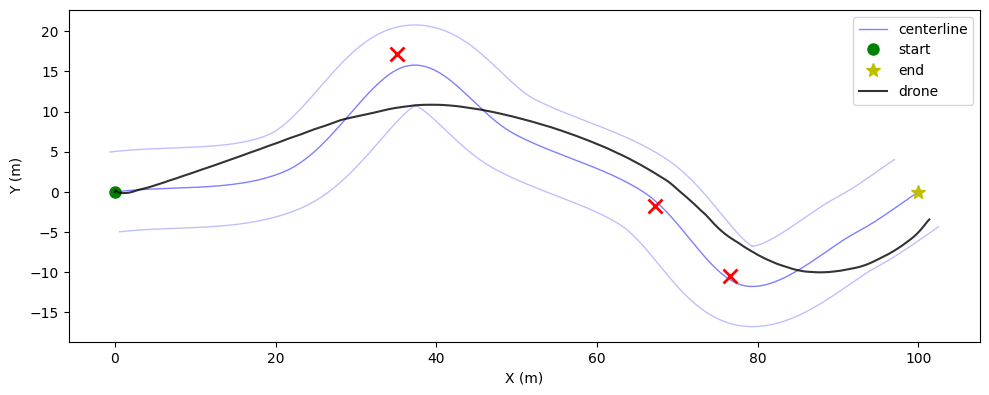

Saved to /content/trajectory.png


In [182]:
from matplotlib import pyplot as plt
pos_arr = np.array(log['pos'])
stride = 10
wp  = env.waypoints[::stride]
tan = env._tangents[::stride]
perp = np.stack([-tan[:,1], tan[:,0]], axis=1)
perp /= np.linalg.norm(perp, axis=1, keepdims=True).clip(1e-8)
r = env.tube_radius

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot((wp[:,:2] + r*perp)[:,0], (wp[:,:2] + r*perp)[:,1], 'b-', lw=1, alpha=0.25)
ax.plot((wp[:,:2] - r*perp)[:,0], (wp[:,:2] - r*perp)[:,1], 'b-', lw=1, alpha=0.25)
ax.plot(wp[:,0], wp[:,1], 'b-', lw=1, alpha=0.5, label='centerline')
for obs in env.obstacles:
    ax.plot(obs['center'][0], obs['center'][1], 'rx', ms=10, mew=2)
ax.plot(*env.waypoints[0,:2],  'go', ms=8, label='start')
ax.plot(*env.waypoints[-1,:2], 'y*', ms=10, label='end')
ax.plot(pos_arr[:,0], pos_arr[:,1], 'k-', lw=1.5, alpha=0.8, label='drone')
ax.set_aspect('equal'); ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)')
ax.legend(); plt.tight_layout()
plt.savefig('/content/trajectory.png', dpi=150)
plt.show()
print('Saved to /content/trajectory.png')

In [ ]:
from google.colab import files
files.download('/content/trajectory.npz')
files.download('/content/trajectory.png')